In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

#### Simplistic keff estimator

In [2]:
def slab_transmission(Sig_s, Sig_a, Sig_f, nu, thickness, N,
                     inactive_cycles=5, active_cycles=50, graph=False):
    Sig_t = Sig_a + Sig_f + Sig_s

    # Sample the initial fission sites randomly
    fission_sites = rng.uniform(0, thickness, N)
    positions = fission_sites.copy()
    weights = nu*np.ones(N)
    mus = rng.uniform(-1, 1, N)
    old_gen = np.sum(weights)

    k = np.zeros(inactive_cycles + active_cycles)

    for cycle in range(inactive_cycles + active_cycles):
        if cycle == 0:
            print("Inactive Cycles...")
        elif cycle == inactive_cycles:
            print("Active Cycles...")

        # make fission site and weights array for this cycle
        fission_sites = np.empty(1)
        # empty function makes me an array of a certain size with random bullshit numbers leftover in ram
        # in practice, the bs number is never used
        # the code deletes this initial number later
        fission_site_weights = np.empty(1)

        for neutron in range(weights.size):
            position = positions[neutron]
            weight = weights[neutron]
            mu = mus[neutron]
            alive = True
            while alive:

                # get distance to collision using Sig_s + Sig_t

                s = -np.log(1-rng.random()) / Sig_t
                # randomly sampled distance using FFMC

                # move the particle
                position += s*mu

                if position > thickness or position < 0:
                    # exited slab
                    alive = False
                else: # sample for scatter or absorb
                    if rng.random() < Sig_s/Sig_t:
                        # scatter, pick new mu
                        mu = rng.uniform(-1, 1)
                    else:
                        alive = False # absorbed, kill particle
                        # sample fission
                        if rng.random() <= Sig_f/(Sig_a+Sig_f):
                            fission_sites = np.append(fission_sites, position)
                            fission_site_weights = np.append(fission_site_weights, weight)

        # Delete the initial site and weight
        fission_site_weights = np.delete(fission_site_weights, 0, axis=0)
        fission_sites = np.delete(fission_sites, 0, axis=0)

        if graph:
            plt.hist(fission_sites, bins=75)
            plt.xlabel("Location(cm)")
            plt.ylabel("Frequency")
            plt.title(f"Cycle {cycle}")
            plt.show()

        # Sample from the fission sites for the next generation
        num_per_site = int(np.ceil(N/fission_sites.size)) # normalize the fission source distribution (q^(n))
        positions = np.empty(1)
        weights = np.empty(1)
        mus = rng.uniform(-1, 1, num_per_site*fission_sites.size)
        for site in range(fission_sites.size):
            site_pos = fission_sites[site]
            site_weight = fission_site_weights[site]
            positions = np.append(positions, site_pos*np.ones((num_per_site, 1)))
            weights = np.append(weights, site_weight*nu/num_per_site*np.ones((num_per_site, 1)))

        # delete the initial site from position and weight vector
        positions = np.delete(positions, 0, axis=0)
        weights = np.delete(weights, 0, axis=0)

        # store keff and update generation
        new_gen = np.sum(weights)
        k[cycle] = new_gen/old_gen
        old_gen = new_gen

        print(f"\tCycle {cycle}, k={k[cycle]:.5f}")

    return k

In [3]:
nu = 2.98
Sig_f = 0.092019
Sig_a = 0.1049514
Sig_s = 0.338232
Sig_tr = 0.4431834
N = 1000
thickness = 7
inactive_cycles = 5
active_cycles = 45
ks = slab_transmission(Sig_s, Sig_a, Sig_f, nu, thickness, N, inactive_cycles=inactive_cycles, active_cycles=active_cycles, graph=False)

k_mean = np.mean(ks)
k_mean_var = np.var(ks[inactive_cycles:])/N
k_std = k_mean_var**0.5
print(f"k mean: {k_mean:.5f}")
print(f"k mean variance: {k_mean_var:.5f}")
print(f"k standard deviation: {k_std:.5f}")

Inactive Cycles...
	Cycle 0, k=1.01022
	Cycle 1, k=1.04901
	Cycle 2, k=1.13762
	Cycle 3, k=1.04906
	Cycle 4, k=1.11492
Active Cycles...
	Cycle 5, k=1.01990
	Cycle 6, k=1.01523
	Cycle 7, k=0.96704
	Cycle 8, k=1.10287
	Cycle 9, k=1.08050
	Cycle 10, k=1.02595
	Cycle 11, k=1.02852
	Cycle 12, k=1.08221
	Cycle 13, k=1.04852
	Cycle 14, k=1.06153
	Cycle 15, k=1.04438
	Cycle 16, k=1.13697
	Cycle 17, k=1.00482
	Cycle 18, k=0.97761
	Cycle 19, k=1.05725
	Cycle 20, k=1.01585
	Cycle 21, k=1.05695
	Cycle 22, k=1.03012
	Cycle 23, k=1.04655
	Cycle 24, k=0.95545
	Cycle 25, k=1.10930
	Cycle 26, k=1.02860
	Cycle 27, k=1.03874
	Cycle 28, k=1.11818
	Cycle 29, k=1.06325
	Cycle 30, k=1.07217
	Cycle 31, k=1.09559
	Cycle 32, k=1.05293
	Cycle 33, k=1.06295
	Cycle 34, k=1.12094
	Cycle 35, k=1.04211
	Cycle 36, k=1.02926
	Cycle 37, k=1.08512
	Cycle 38, k=1.05028
	Cycle 39, k=1.05161
	Cycle 40, k=1.05589
	Cycle 41, k=1.06630
	Cycle 42, k=0.98018
	Cycle 43, k=1.07111
	Cycle 44, k=1.04485
	Cycle 45, k=1.01684
	Cycle 4

#### Three k-eigenvalue estimators

In [4]:
# Collision Estimator
def slab_estimator(Sig_s, Sig_a, Sig_f, nu, thickness, N,
                     inactive_cycles=5, active_cycles=50, graph=False):
    Sig_t = Sig_a + Sig_f + Sig_s

    # Sample the initial fission sites randomly
    fission_sites = rng.uniform(0, thickness, N)
    positions = fission_sites.copy()
    weights = nu*np.ones(N)
    mus = rng.uniform(-1, 1, N)
    old_gen = np.sum(weights)

    k = np.zeros(inactive_cycles + active_cycles)
    kc = np.zeros(inactive_cycles + active_cycles)
    ka = np.zeros(inactive_cycles + active_cycles)
    kp = np.zeros(inactive_cycles + active_cycles)
    Shannon_entropy = np.zeros(inactive_cycles+active_cycles)
    for cycle in range(inactive_cycles + active_cycles):
        if cycle == 0:
            print("Inactive Cycles...")
        elif cycle == inactive_cycles:
            print("Active Cycles...")

        # make fission site and weights array for this cycle
        fission_sites = np.empty(1)
        # empty function makes me an array of a certain size with random bullshit numbers leftover in ram
        # in practice, the bs number is never used
        # the code deletes this initial number later
        fission_site_weights = np.empty(1)

        # Now we have different tallies
        #  these tallies track number of fission neutrons produced
        collision_tally = 0.0
        pathlength_tally = 0.0
        absorption_tally = 0.0
        
        
        for neutron in range(weights.size):
            position = positions[neutron]
            weight = weights[neutron]
            mu = mus[neutron]
            alive = True
            while alive:

                # get distance to collision using Sig_s + Sig_t

                s = -np.log(1-rng.random()) / Sig_t
                # randomly sampled distance using FFMC

                # move the particle
                position += s*mu

                # add to pathlength tally
                pathlength_tally += weight * nu * Sig_f * s
                if position > thickness or position < 0:
                    # exited slab
                    alive = False
                else: # a collision happened and we will tally it
                    collision_tally += weight * nu* Sig_f/Sig_t
                    if rng.random() < Sig_s/Sig_t:
                        # scatter, pick new mu
                        mu = rng.uniform(-1, 1)
                    else:
                        alive = False # absorbed, kill particle
                        # add to absorption tally
                        absorption_tally += weight * nu * Sig_f/(Sig_a + Sig_f)
                        
                        # sample fission
                        if rng.random() <= Sig_f/(Sig_a+Sig_f):
                            fission_sites = np.append(fission_sites, position)
                            fission_site_weights = np.append(fission_site_weights, weight)

        # Delete the initial site and weight
        fission_site_weights = np.delete(fission_site_weights, 0, axis=0)
        fission_sites = np.delete(fission_sites, 0, axis=0)

        if graph:
            plt.hist(fission_sites, bins=75)
            plt.xlabel("Location(cm)")
            plt.ylabel("Frequency")
            plt.title(f"Cycle {cycle}")
            plt.show()

        # Sample from the fission sites for the next generation
        num_per_site = int(np.ceil(N/fission_sites.size)) # normalize the fission source distribution (q^(n))
        positions = np.empty(1)
        weights = np.empty(1)
        mus = rng.uniform(-1, 1, num_per_site*fission_sites.size)
        for site in range(fission_sites.size):
            site_pos = fission_sites[site]
            site_weight = fission_site_weights[site]
            positions = np.append(positions, site_pos*np.ones((num_per_site, 1)))
            weights = np.append(weights, site_weight*nu/num_per_site*np.ones((num_per_site, 1)))

        # delete the initial site from position and weight vector
        positions = np.delete(positions, 0, axis=0)
        weights = np.delete(weights, 0, axis=0)

        # NOTE: k = neutrons produced / neutrons absorbed
        kc[cycle] = collision_tally / np.sum(weights)
        ka[cycle] = absorption_tally / np.sum(weights)
        kp[cycle] = pathlength_tally / np.sum(weights)

        # Shannon Entropy
        fission_distribution, edges = np.histogram(fission_sites, bins=7, range=(0,7))
        # print(fission_distribution)
        # print(fission_sites.size)
        Shannon_sum = 0
        for bin in range(fission_distribution.size):
            pj = fission_distribution[bin]/(fission_sites.size)
            if pj>=0:
                # print(pj)
                Shannon_sum += pj*np.log2(pj)
        Shannon_entropy[cycle] = -Shannon_sum
        # print(Shannon_entropy)
        
        # store keff and update generation
        # new_gen = np.sum(weights)
        # k[cycle] = new_gen/old_gen
        # old_gen = new_gen

        print("Collision Estimator")
        print(f"\tCycle {cycle}, k={kc[cycle]:.5f}")
        print("Absorption Estimator")
        print(f"\tCycle {cycle}, k={ka[cycle]:.5f}")
        print("Path-Length Estimator")
        print(f"\tCycle {cycle}, k={kp[cycle]:.5f}")
        print("*************************************")

    return kc, ka, kp, Shannon_entropy

In [5]:
kc, ka, kp, shannon = slab_estimator(Sig_s, Sig_a, Sig_f, nu, thickness, N, inactive_cycles=inactive_cycles, active_cycles=active_cycles, graph=False)

Inactive Cycles...
Collision Estimator
	Cycle 0, k=1.01249
Absorption Estimator
	Cycle 0, k=1.03395
Path-Length Estimator
	Cycle 0, k=1.12388
*************************************
Collision Estimator
	Cycle 1, k=1.04029
Absorption Estimator
	Cycle 1, k=1.05961
Path-Length Estimator
	Cycle 1, k=1.13790
*************************************
Collision Estimator
	Cycle 2, k=1.06540
Absorption Estimator
	Cycle 2, k=1.03607
Path-Length Estimator
	Cycle 2, k=1.18650
*************************************
Collision Estimator
	Cycle 3, k=1.00833
Absorption Estimator
	Cycle 3, k=0.99286
Path-Length Estimator
	Cycle 3, k=1.14351
*************************************
Collision Estimator
	Cycle 4, k=0.99274
Absorption Estimator
	Cycle 4, k=0.96954
Path-Length Estimator
	Cycle 4, k=1.12136
*************************************
Active Cycles...
Collision Estimator
	Cycle 5, k=1.01675
Absorption Estimator
	Cycle 5, k=1.01506
Path-Length Estimator
	Cycle 5, k=1.08396
************************************

In [6]:
k_col_mean = np.mean(kc)
k_abs_mean = np.mean(ka)
k_path_mean = np.mean(kp)

# Variances
S_cc = np.var(kc, ddof=1)
S_aa = np.var(ka, ddof=1)
S_pp = np.var(kp, ddof=1)
# Covariances
S_pc = np.cov(kp, kc, bias=False)[0, 1]
S_ac = np.cov(ka, kc, bias=False)[0, 1]
S_ap = np.cov(ka, kp, bias=False)[0, 1]

fc = S_aa*(S_pp - S_pc) - S_pp*S_ac + S_ap*(S_ac + S_pc - S_ap)
fa = S_pp*(S_cc - S_ac) - S_cc*S_ap + S_pc*(S_ap + S_ac - S_pc)
fp = S_cc*(S_aa - S_ap) - S_aa*S_pc + S_ac*(S_pc + S_ap - S_ac)

k = (fc*k_col_mean + fa*k_abs_mean + fp*k_path_mean) / (fc + fa + fp)
print(f"keff calculated from the three estimators: k = {k:.5f}")

keff calculated from the three estimators: k = 0.96929


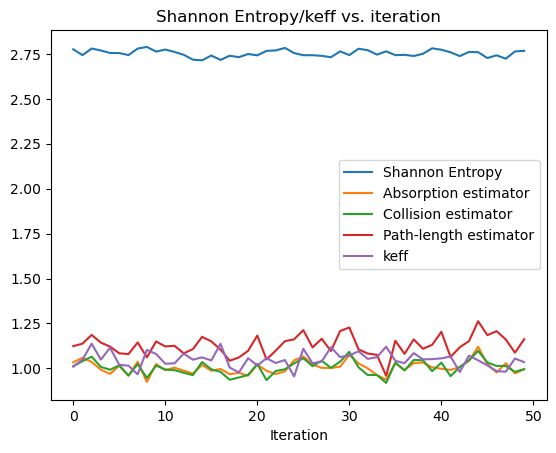

In [7]:
xs = np.arange(inactive_cycles+active_cycles)
ys = shannon

# print(ys)
plt.plot(xs, ys, label="Shannon Entropy")
plt.plot(xs, ka, label="Absorption estimator")
plt.plot(xs, kc, label="Collision estimator")
plt.plot(xs, kp, label="Path-length estimator")
plt.plot(xs, ks, label="keff")
plt.title("Shannon Entropy/keff vs. iteration")
plt.xlabel("Iteration")
plt.legend()
plt.show()